In [4]:
# !pip install imbalanced-learn

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

In [6]:
df = pd.read_csv("speeddating.csv")

leakage_cols = [
    "attractive_o", "sinsere_o", "intelligence_o", "funny_o", "ambitous_o", "shared_interests_o",
    "attractive_partner", "sincere_partner", "intelligence_partner", "funny_partner",
    "ambition_partner", "shared_interests_partner",
    "like", "guess_prob_liked", "met", "decision", "decision_o"
]

system_cols = ["has_null", "wave"]

d_cols = [col for col in df.columns if col.startswith("d_") and col != "d_age"]

all_drops = leakage_cols + ["has_null", "wave"] + d_cols
df = df.drop(columns=all_drops, errors="ignore")

for col in df.select_dtypes(include=["object"]).columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r"^b['\"](.*)['\"]$", r"\1", regex=True)
    )

df = df.replace(r"^\s*$", np.nan, regex=True).replace("nan", np.nan)

df = df.apply(pd.to_numeric, errors="ignore")
df.head(20)

/tmp/ipykernel_3005/23250984.py:26: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


,gender,age,age_o,d_age,race,race_o,samerace,importance_same_race,importance_same_religion,field,...,movies,concerts,music,shopping,yoga,interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,match
0,female,21.0,27.0,6.0,Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,Law,...,10.0,10.0,9.0,8.0,1.0,0.14,3.0,2.0,4.0,0
1,female,21.0,22.0,1.0,Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,Law,...,10.0,10.0,9.0,8.0,1.0,0.54,3.0,2.0,4.0,0
2,female,21.0,22.0,1.0,Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,2.0,4.0,Law,...,10.0,10.0,9.0,8.0,1.0,0.16,3.0,2.0,4.0,1
3,female,21.0,23.0,2.0,Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,Law,...,10.0,10.0,9.0,8.0,1.0,0.61,3.0,2.0,4.0,1
4,female,21.0,24.0,3.0,Asian/Pacific Islander/Asian-American,Latino/Hispanic American,0,2.0,4.0,Law,...,10.0,10.0,9.0,8.0,1.0,0.21,3.0,2.0,4.0,1
5,female,21.0,25.0,4.0,Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,Law,...,10.0,10.0,9.0,8.0,1.0,0.25,3.0,2.0,4.0,0
6,female,21.0,30.0,9.0,Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,Law,...,10.0,10.0,9.0,8.0,1.0,0.34,3.0,2.0,4.0,0
7,female,21.0,27.0,6.0,Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,Law,...,10.0,10.0,9.0,8.0,1.0,0.50,3.0,2.0,4.0,0
8,female,21.0,28.0,7.0,Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,Law,...,10.0,10.0,9.0,8.0,1.0,0.28,3.0,2.0,4.0,1
9,female,21.0,24.0,3.0,Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,Law,...,10.0,10.0,9.0,8.0,1.0,-0.36,3.0,2.0,4.0,0


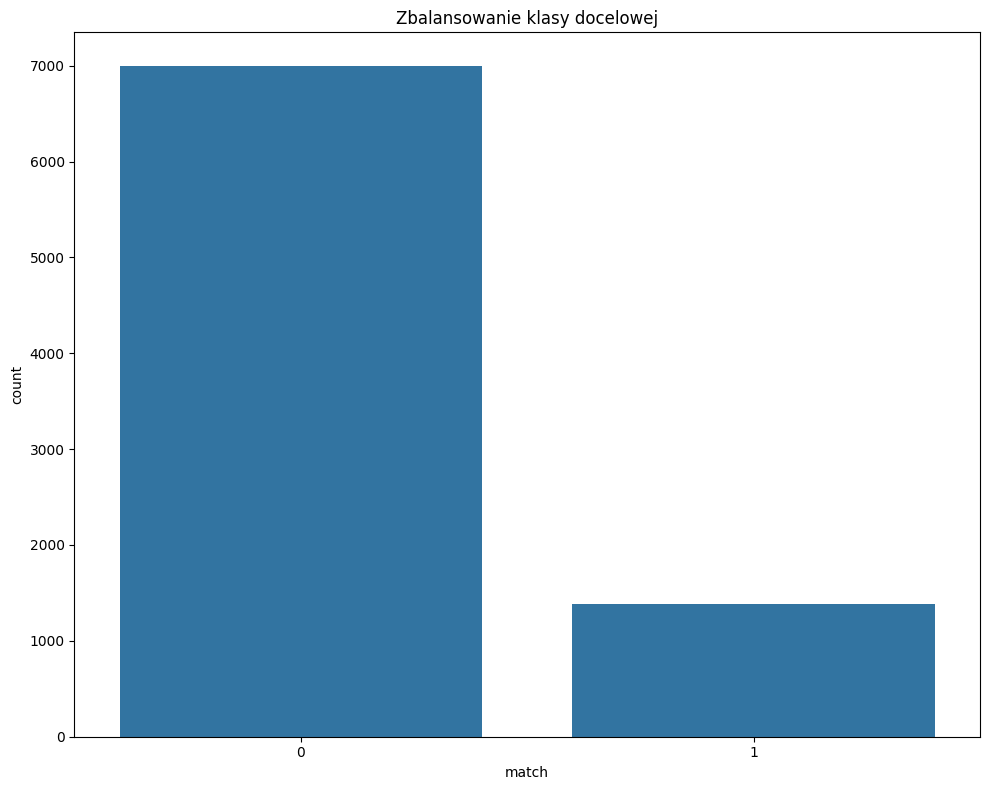

In [7]:
fig, ax = plt.subplots(figsize=(10,8))
sns.countplot(df, x="match", ax=ax)
plt.title("Zbalansowanie klasy docelowej")
plt.tight_layout()

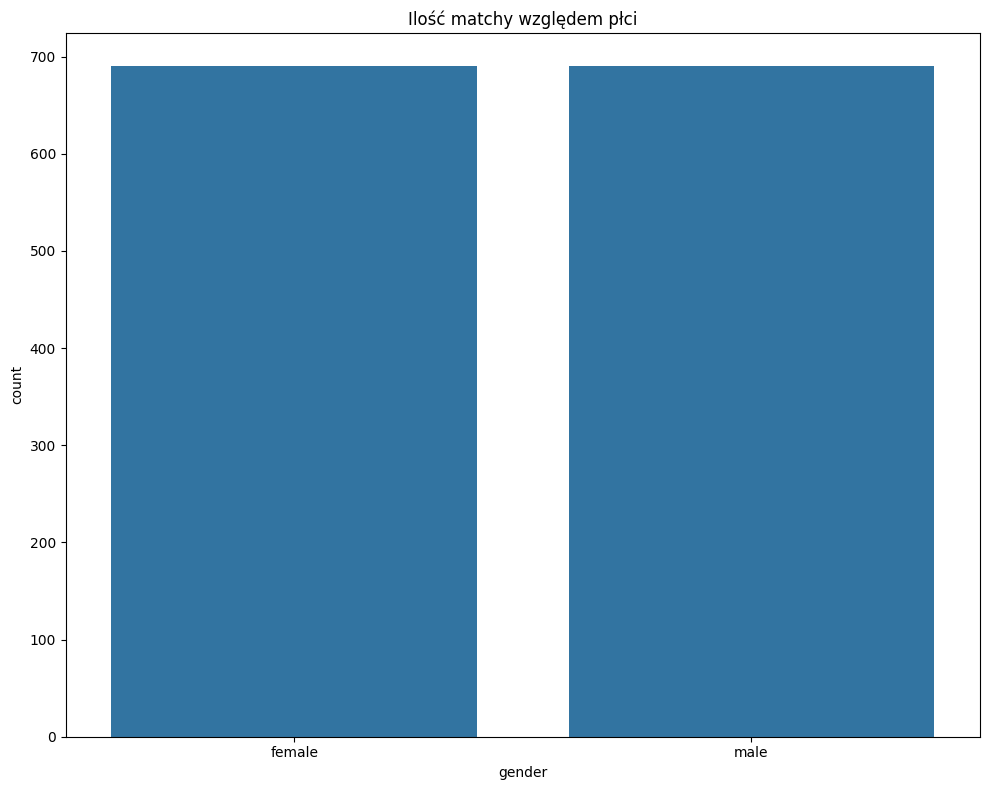

In [8]:
fig, ax = plt.subplots(figsize=(10,8))
sns.countplot(data=df[df["match"] == 1], x="gender", ax=ax)
plt.title("Ilość matchy względem płci")
plt.tight_layout()

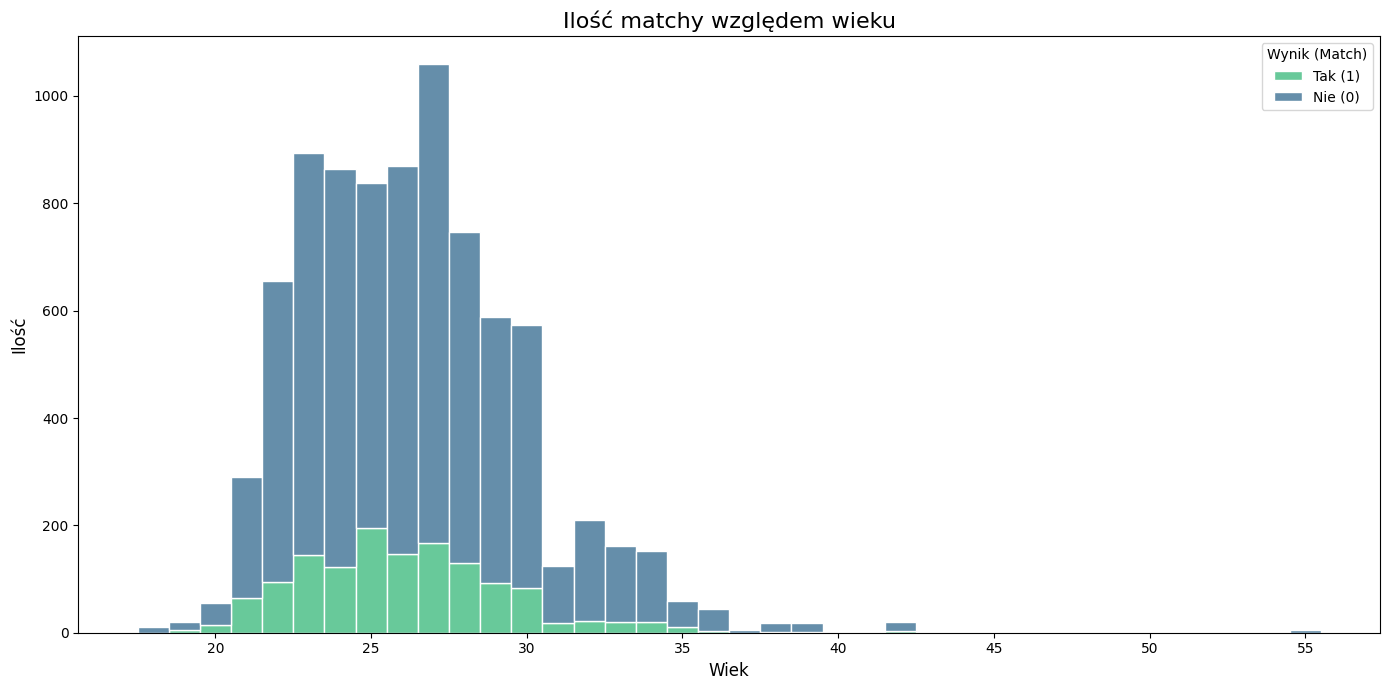

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))

sns.histplot(
    data=df.dropna(subset=["age"]),
    x="age",
    hue="match",
    multiple="stack",
    discrete=True,
    palette="viridis",
    edgecolor="white",
    ax=ax
)

plt.title("Ilość matchy względem wieku", fontsize=16)
plt.xlabel("Wiek", fontsize=12)
plt.ylabel("Ilość", fontsize=12)

plt.legend(title="Wynik (Match)", labels=["Tak (1)", "Nie (0)"])

plt.tight_layout()
plt.show()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 49 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   gender                         8378 non-null   object 
 1   age                            8283 non-null   float64
 2   age_o                          8274 non-null   float64
 3   d_age                          8378 non-null   float64
 4   race                           8378 non-null   object 
 5   race_o                         8378 non-null   object 
 6   samerace                       8378 non-null   int64  
 7   importance_same_race           8299 non-null   float64
 8   importance_same_religion       8299 non-null   float64
 9   field                          8378 non-null   object 
 10  pref_o_attractive              8289 non-null   float64
 11  pref_o_sincere                 8289 non-null   float64
 12  pref_o_intelligence            8289 non-null   f

In [11]:
df.select_dtypes(include="number").describe()

,age,age_o,d_age,samerace,importance_same_race,importance_same_religion,pref_o_attractive,pref_o_sincere,pref_o_intelligence,pref_o_funny,...,movies,concerts,music,shopping,yoga,interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,match
count,8283.000000,8274.000000,8378.000000,8378.000000,8299.000000,8299.000000,8289.000000,8289.000000,8289.000000,8280.000000,...,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8220.000000,8277.000000,1800.000000,7205.000000,8378.000000
mean,26.358928,26.364999,4.185605,0.395799,3.784793,3.651645,22.495347,17.396867,20.270759,17.459714,...,7.919629,6.825401,7.851066,5.631281,4.339197,0.196010,5.534131,5.570556,3.207814,0.164717
std,3.566763,3.563648,4.596171,0.489051,2.845708,2.805237,12.569802,7.044003,6.782895,6.085526,...,1.700927,2.156283,1.791827,2.608913,2.717612,0.303539,1.734059,4.762569,2.444813,0.370947
min,18.000000,18.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,-0.830000,1.000000,0.000000,0.000000,0.000000
25%,24.000000,24.000000,1.000000,0.000000,1.000000,1.000000,15.000000,15.000000,17.390000,15.000000,...,7.000000,5.000000,7.000000,4.000000,2.000000,-0.020000,5.000000,2.000000,2.000000,0.000000
50%,26.000000,26.000000,3.000000,0.000000,3.000000,3.000000,20.000000,18.370000,20.000000,18.000000,...,8.000000,7.000000,8.000000,6.000000,4.000000,0.210000,6.000000,4.000000,3.000000,0.000000
75%,28.000000,28.000000,5.000000,1.000000,6.000000,6.000000,25.000000,20.000000,23.810000,20.000000,...,9.000000,8.000000,9.000000,8.000000,7.000000,0.430000,7.000000,8.000000,4.000000,0.000000
max,55.000000,55.000000,37.000000,1.000000,10.000000,10.000000,100.000000,60.000000,50.000000,50.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,0.910000,10.000000,20.000000,18.000000,1.000000


# Przygotowanie danych

In [12]:
print("Duplikaty: ", df.duplicated().sum())
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

Duplikaty:  13


In [13]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df)) * 100

summary = (
    pd.DataFrame({"Brakujące": null_counts, "%": null_pct})
    .sort_values(by="%", ascending=False)
)

print(summary.head(5))

                               Brakujące          %
expected_num_interested_in_me       6573  78.577406
expected_num_matches                1172  14.010759
interests_correlate                  145   1.733413
shared_interests_important           121   1.446503
pref_o_shared_interests              116   1.386730


In [14]:
df.drop("expected_num_interested_in_me", axis=1, inplace=True)

In [15]:
static_cols = [
    "gender", "age", "race", "field",
    "attractive", "sincere", "intelligence", "funny", "ambition",
    "sports", "tvsports", "exercise", "dining", "museums", "art",
    "hiking", "gaming", "clubbing", "reading", "tv", "theater",
    "movies", "concerts", "music", "shopping", "yoga"
]

user_fingerprints = df[static_cols].astype(str).agg('-'.join, axis=1)

In [16]:
for col in df.select_dtypes(exclude="number").columns:
    print(f"{col} - {len(df[col].unique())}")

gender - 2
race - 6
race_o - 6
field - 260


In [17]:
df["field"] = df["field"].astype(str).str.lower().str.strip()

top_10_fields = df["field"].value_counts().head(30)
print(top_10_fields)

field
business                  631
law                       602
mba                       465
social work               414
international affairs     287
electrical engineering    223
psychology                177
sociology                 140
engineering               126
education                 123
biology                   122
finance                   113
film                      107
political science         105
mathematics                95
chemistry                  93
medicine                   92
biomedical engineering     84
physics                    77
business [mba]             77
clinical psychology        76
biochemistry               70
economics                  67
?                          63
genetics                   63
school psychology          56
operations research        56
journalism                 55
microbiology               54
music education            54
Name: count, dtype: int64


In [18]:
len(df["field"].unique())

220

In [19]:
import pandas as pd
import numpy as np

def group_academic_fields_v2(field_name):
    if pd.isna(field_name) or field_name == "?":
        return "unknown"

    field = str(field_name).lower().strip()

    if any(w in field for w in ["business", "mba", "financ", "econ", "management", "operations", "money", "marketing", "consulting", "fundraising"]):
        return "business_finance"

    elif any(w in field for w in ["law", "legal", "affair", "policy", "political", "public administration", "human rights", "development", "security", "sipa"]):
        return "law_policy"

    elif any(w in field for w in ["engineering", "math", "stat", "physics", "chemist", "biolog", "science", "tech", "genetics", "neuro", "earth", "climate", "ecology", "architecture", "quant", "qmss", "informatics", "dynamics"]):
        return "stem"

    elif any(w in field for w in ["psychology", "sociology", "anthropology", "history", "religion", "philosophy", "american studies", "studies"]):
        return "social_sciences_humanities"

    elif any(w in field for w in ["social work", "education", "teaching", "tc ", "ed.", "tesol", "curriculum", "instructional", "pedagogy"]):
        return "education_social_work"

    elif any(w in field for w in ["film", "journalism", "music", "art", "literature", "english", "theater", "theatre", "acting", "writing", "mfa", "language", "polish", "french", "chinese", "japanese", "classics", "communications", "media", "soa"]):
        return "arts_media_communications"

    elif any(w in field for w in ["medicine", "medical", "nursing", "health", "clinical", "pathology", "nutrition", "nutritiron", "epidemiology", "premed"]):
        return "healthcare_medical"

    else:
        return "other"

df["field"] = df["field"].apply(group_academic_fields_v2)

print(df["field"].value_counts())

field
business_finance              2075
stem                          1818
law_policy                    1421
education_social_work          925
social_sciences_humanities     879
arts_media_communications      664
healthcare_medical             319
other                          201
unknown                         63
Name: count, dtype: int64


In [20]:
df["gender"] = np.where(df["gender"] == "male", 1, 0)

In [21]:
def split_by_user_fingerprint(df, fingerprints, test_samples_per_user=5):
    fingerprint_counts = fingerprints.value_counts()
    eligible_users = fingerprint_counts[fingerprint_counts >= test_samples_per_user].index

    test_indices = []

    for user_id in eligible_users:
        user_row_indices = fingerprints[fingerprints == user_id].index
        chosen_for_test = np.random.choice(user_row_indices, size=test_samples_per_user, replace=False)
        test_indices.extend(chosen_for_test)

    df_test = df.loc[test_indices].copy()
    df_train = df.drop(index=test_indices).copy()

    return df_train, df_test

# Uczenie

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin

df_train, df_test = split_by_user_fingerprint(df, user_fingerprints)

X_train = df_train.drop(columns=["match"])
y_train = df_train["match"]

X_test = df_test.drop(columns=["match"])
y_test = df_test["match"]

class PandasMedianImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.medians_ = X.select_dtypes(include=['float64', 'int64']).median()
        return self

    def transform(self, X):
        return X.fillna(self.medians_)

def engineer_preferences(X_df):
    X_out = X_df.copy()

    my_pref_cols = ["attractive_important", "sincere_important", "intellicence_important",
                    "funny_important", "ambtition_important", "shared_interests_important"]

    partner_pref_cols = ["pref_o_attractive", "pref_o_sincere", "pref_o_intelligence",
                         "pref_o_funny", "pref_o_ambitious", "pref_o_shared_interests"]

    my_pref_sums = X_out[my_pref_cols].sum(axis=1)
    partner_pref_sums = X_out[partner_pref_cols].sum(axis=1)

    for col in my_pref_cols:
        X_out[f"{col}_norm"] = X_out[col] / my_pref_sums.replace(0, np.nan)

    for col in partner_pref_cols:
        X_out[f"{col}_norm"] = X_out[col] / partner_pref_sums.replace(0, np.nan)

    X_out["diff_importance_attractive"] = abs(X_out["attractive_important_norm"] - X_out["pref_o_attractive_norm"])
    X_out["diff_importance_sincere"] = abs(X_out["sincere_important_norm"] - X_out["pref_o_sincere_norm"])
    X_out["diff_importance_intelligence"] = abs(X_out["intellicence_important_norm"] - X_out["pref_o_intelligence_norm"])
    X_out["diff_importance_funny"] = abs(X_out["funny_important_norm"] - X_out["pref_o_funny_norm"])
    X_out["diff_importance_ambition"] = abs(X_out["ambtition_important_norm"] - X_out["pref_o_ambitious_norm"])
    X_out["diff_importance_shared_interests"] = abs(X_out["shared_interests_important_norm"] - X_out["pref_o_shared_interests_norm"])

    self_rating_cols = ["attractive", "sincere", "intelligence", "funny", "ambition"]
    X_out["total_self_rating"] = X_out[self_rating_cols].sum(axis=1)

    cols_to_drop = my_pref_cols + partner_pref_cols
    X_out = X_out.drop(columns=cols_to_drop)

    return X_out.fillna(0)

processing_pipeline = Pipeline(steps=[
    ("imputer", PandasMedianImputer()),
    ("engineer", FunctionTransformer(engineer_preferences))
])

X_train_processed = processing_pipeline.fit_transform(X_train)
X_test_processed = processing_pipeline.transform(X_test)

WIĘKSZOŚCIOWY
                   pre       rec       spe        f1       geo       iba       sup

          0       0.84      1.00      0.00      0.91      0.00      0.00      2295
          1       0.00      0.00      1.00      0.00      0.00      0.00       440

avg / total       0.70      0.84      0.16      0.77      0.00      0.00      2735





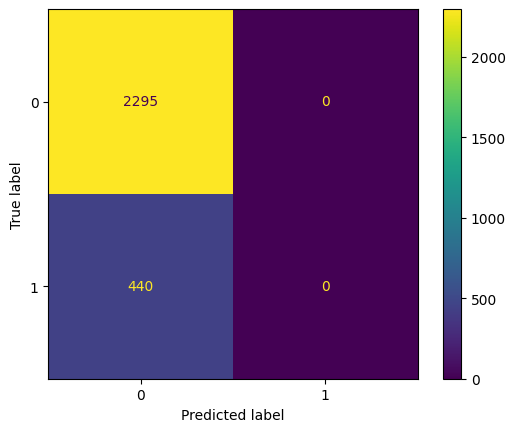

In [23]:
from sklearn.dummy import DummyClassifier
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

dummy_majority = DummyClassifier(strategy="most_frequent")
dummy_majority.fit(X_train_processed, y_train)

y_pred_majority = dummy_majority.predict(X_test_processed)

print("WIĘKSZOŚCIOWY")
print(classification_report_imbalanced(y_test, y_pred_majority, zero_division=0))
print("\n")

cm = confusion_matrix(y_test, y_pred_majority)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

LOSOWY
                   pre       rec       spe        f1       geo       iba       sup

          0       0.84      0.83      0.16      0.84      0.37      0.15      2295
          1       0.16      0.16      0.83      0.16      0.37      0.13       440

avg / total       0.73      0.73      0.27      0.73      0.37      0.14      2735





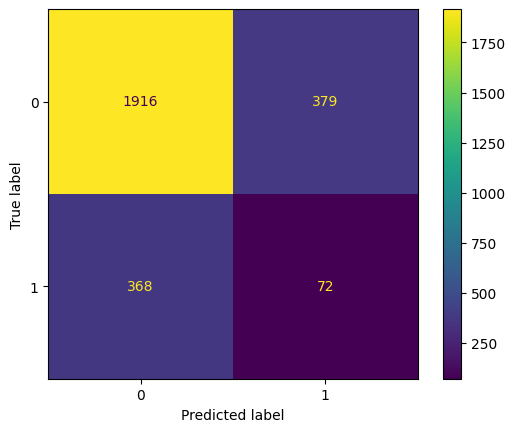

In [24]:
dummy_random = DummyClassifier(strategy="stratified", random_state=42)
dummy_random.fit(X_train_processed, y_train)

y_pred_random = dummy_random.predict(X_test_processed)

print("LOSOWY")
print(classification_report_imbalanced(y_test, y_pred_random))
print("\n")

cm = confusion_matrix(y_test, y_pred_random)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = ["race", "race_o", "field"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ],
    remainder='passthrough'
)

                   pre       rec       spe        f1       geo       iba       sup

          0       0.88      0.54      0.63      0.67      0.58      0.33      2295
          1       0.21      0.63      0.54      0.31      0.58      0.34       440

avg / total       0.77      0.55      0.61      0.61      0.58      0.34      2735



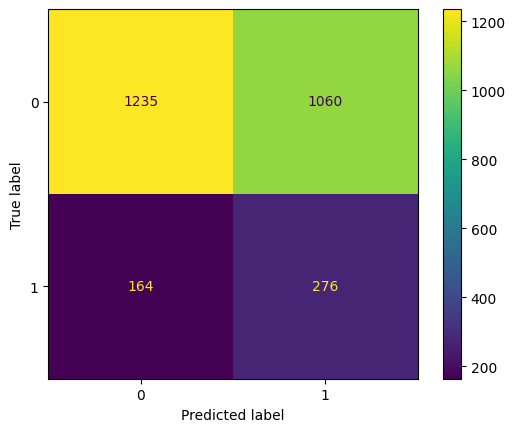

In [26]:
from sklearn.tree import DecisionTreeClassifier

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=42
    ))
])

tree_pipeline.fit(X_train_processed, y_train)

y_pred_tree = tree_pipeline.predict(X_test_processed)

print(classification_report_imbalanced(y_test, y_pred_tree))

cm = confusion_matrix(y_test, y_pred_tree)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

def plot_tsne(X, y, ax, title="t-SNE", sample_size=1500, random_state=42):
    if len(X) > sample_size:
        X_plot, _, y_plot, _ = train_test_split(
            X, y,
            train_size=sample_size,
            stratify=y,
            random_state=random_state
        )
    else:
        X_plot, y_plot = X, y

    tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=random_state, n_jobs=-1)
    X_tsne = tsne.fit_transform(X_plot)

    tsne_df = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])

    tsne_df["Match"] = y_plot.values if isinstance(y_plot, pd.Series) else y_plot

    tsne_df = tsne_df.sort_values(by='Match')

    sns.scatterplot(
        data=tsne_df,
        x="TSNE1",
        y="TSNE2",
        hue="Match",
        alpha=0.8,
        ax=ax
    )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("t-SNE wymiar 1")
    ax.set_ylabel("t-SNE wymiar 2")

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ["Brak Matcha (0)", "Match (1)"], title="Wynik", loc="best")

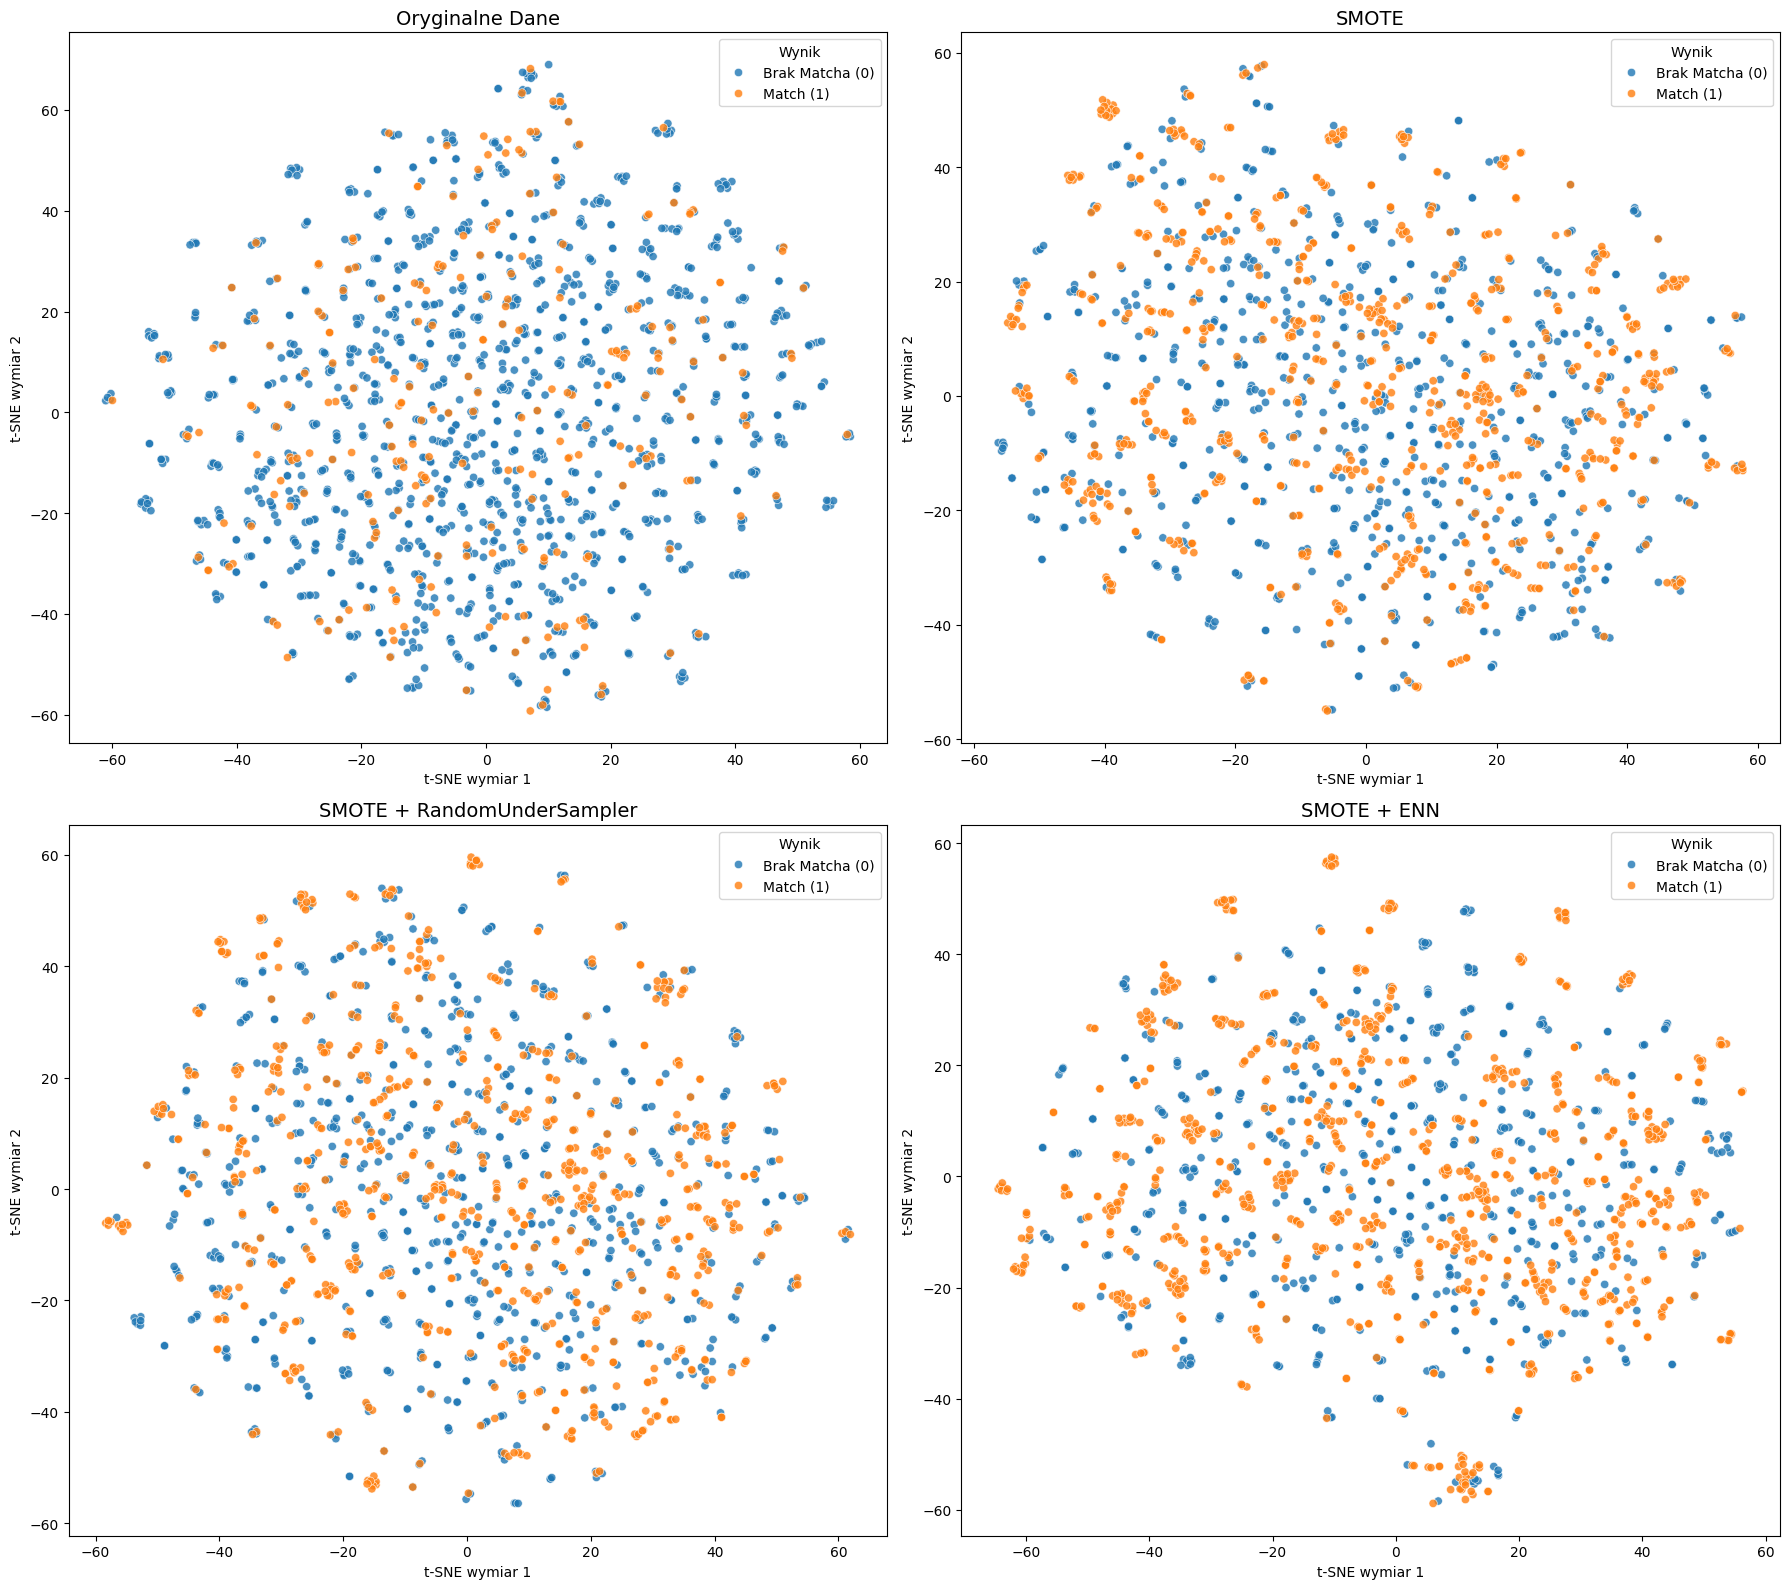

In [28]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = ["race", "race_o", "field"]
numeric_cols = [col for col in X_train_processed.columns if col not in categorical_cols]

tsne_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

X_train_tsne_ready = tsne_preprocessor.fit_transform(X_train_processed)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tsne_ready, y_train)

smote_rus_pipe = ImbPipeline([
    ("smote", SMOTE(sampling_strategy=0.5, random_state=42)),
    ("rus", RandomUnderSampler(sampling_strategy=1.0, random_state=42))
])
X_smote_rus, y_smote_rus = smote_rus_pipe.fit_resample(X_train_tsne_ready, y_train)

smote_enn = SMOTEENN(random_state=42, n_jobs=-1)
X_sme, y_sme = smote_enn.fit_resample(X_train_tsne_ready, y_train)

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()

plot_tsne(
    X_train_tsne_ready,
    y_train,
    ax=axes[0],
    title="Oryginalne Dane"
)

plot_tsne(
    X_train_smote,
    y_train_smote,
    ax=axes[1],
    title="SMOTE"
)

plot_tsne(
    X_smote_rus,
    y_smote_rus,
    ax=axes[2],
    title="SMOTE + RandomUnderSampler"
)

plot_tsne(
    X_sme,
    y_sme,
    ax=axes[3],
    title="SMOTE + ENN"
)

plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

def plot_evaluation_metrics(y_true, y_pred, y_pred_proba, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=axes[0])
    axes[0].set_title(f"CM - {title_prefix}")

    RocCurveDisplay.from_predictions(
        y_true, y_pred_proba,
        ax=axes[1]
    )
    axes[1].plot([0, 1], [0, 1], "k--", label="Losowe zgadywanie")
    axes[1].legend(loc="best")
    axes[1].set_title(f"ROC - {title_prefix}")

    PrecisionRecallDisplay.from_predictions(
        y_true, y_pred_proba,
        ax=axes[2]
    )
    axes[2].set_title(f"PR - {title_prefix}")

    plt.tight_layout()
    plt.show()

Najlepsze parametry: {'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
                   pre       rec       spe        f1       geo       iba       sup

          0       0.89      0.74      0.50      0.81      0.61      0.38      2295
          1       0.27      0.50      0.74      0.35      0.61      0.36       440

avg / total       0.79      0.70      0.54      0.73      0.61      0.38      2735



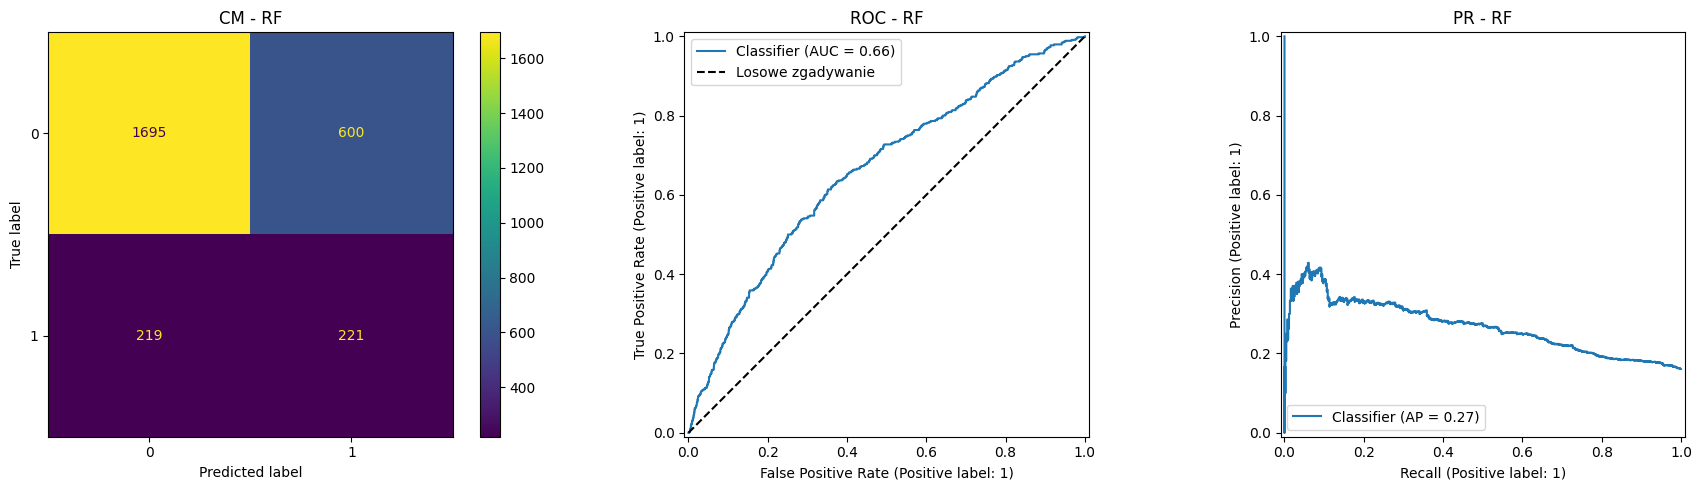

In [30]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2, 5, 10]
}

rf_base_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
])

rf_grid = GridSearchCV(
    estimator=rf_base_pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)

rf_grid.fit(X_train_processed, y_train)

print(f"Najlepsze parametry: {rf_grid.best_params_}")
best_rf_model = rf_grid.best_estimator_

y_pred_rf = best_rf_model.predict(X_test_processed)
y_pred_proba_rf = best_rf_model.predict_proba(X_test_processed)[:, 1]

print(classification_report_imbalanced(y_test, y_pred_rf))

plot_evaluation_metrics(y_test, y_pred_rf, y_pred_proba_rf, "RF")

Najlepsze parametry: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
                   pre       rec       spe        f1       geo       iba       sup

          0       0.90      0.60      0.67      0.72      0.63      0.40      2295
          1       0.24      0.67      0.60      0.35      0.63      0.40       440

avg / total       0.80      0.61      0.66      0.66      0.63      0.40      2735



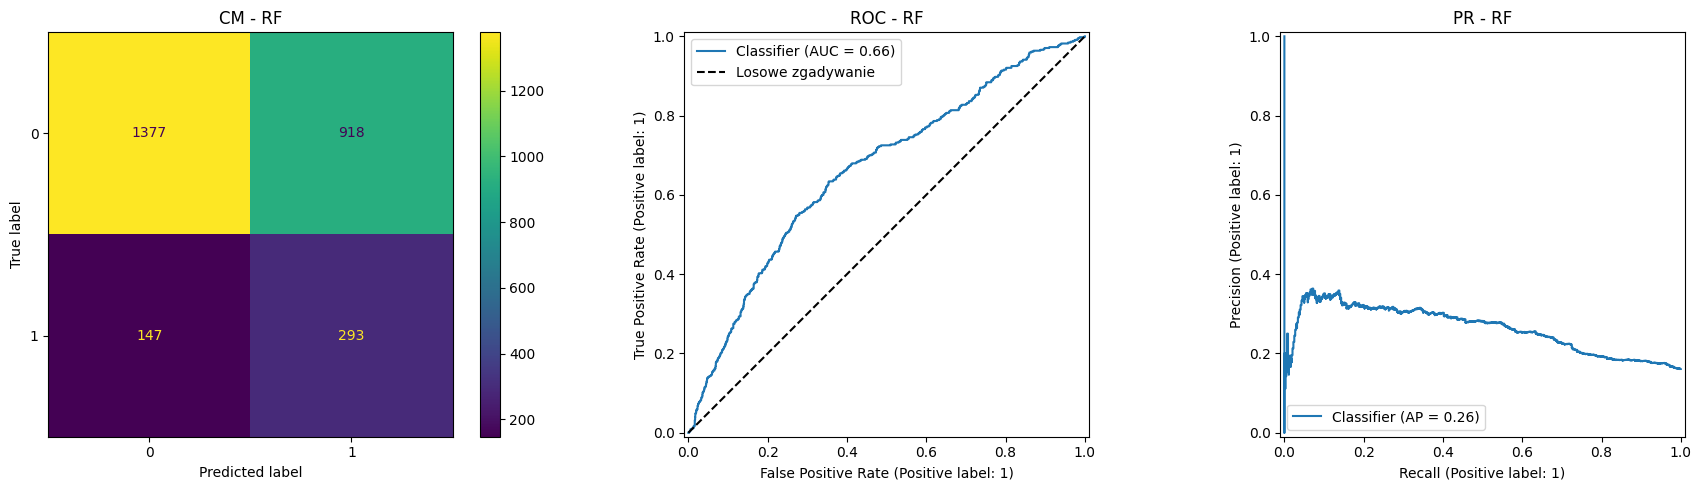

In [31]:
brf_base_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", BalancedRandomForestClassifier(
        sampling_strategy="auto",
        replacement=False,
        random_state=42,
        n_jobs=-1
    ))
])

brf_grid = GridSearchCV(
    estimator=brf_base_pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)

brf_grid.fit(X_train_processed, y_train)

print(f"Najlepsze parametry: {brf_grid.best_params_}")
best_brf_model = brf_grid.best_estimator_

y_pred_brf = best_brf_model.predict(X_test_processed)
y_pred_proba_brf = best_brf_model.predict_proba(X_test_processed)[:, 1]

print(classification_report_imbalanced(y_test, y_pred_brf))

plot_evaluation_metrics(y_test, y_pred_brf, y_pred_proba_brf, "RF")

In [32]:
resamplers = {
    "SMOTE": SMOTE(random_state=42),
    "SMOTE + RUS": ImbPipeline(steps=[
        ("smote", SMOTE(sampling_strategy=0.5, random_state=42)),
        ("RUS", RandomUnderSampler(sampling_strategy=1.0, random_state=42)),
    ]),
    "SMOTE + ENN": SMOTEENN(random_state=42)
}


def train_and_plot_resampler(name, *resampler_steps):
    vanilla_rf = RandomForestClassifier(
      n_estimators=100,
      max_depth=5,
      random_state=42,
      min_samples_split=2,
      n_jobs=-1
    )

    steps = [("preprocessor", preprocessor)]
    steps.extend(resampler_steps)
    steps.append(("classifier", vanilla_rf))

    pipeline = ImbPipeline(steps=steps)

    pipeline.fit(X_train_processed, y_train)
    y_pred = pipeline.predict(X_test_processed)
    y_pred_proba = pipeline.predict_proba(X_test_processed)[:, 1]

    print(classification_report_imbalanced(y_test, y_pred))

    plot_evaluation_metrics(y_test, y_pred, y_pred_proba, title_prefix=name)
    return pipeline

                   pre       rec       spe        f1       geo       iba       sup

          0       0.87      0.80      0.36      0.83      0.53      0.30      2295
          1       0.26      0.36      0.80      0.30      0.53      0.27       440

avg / total       0.77      0.73      0.43      0.75      0.53      0.29      2735



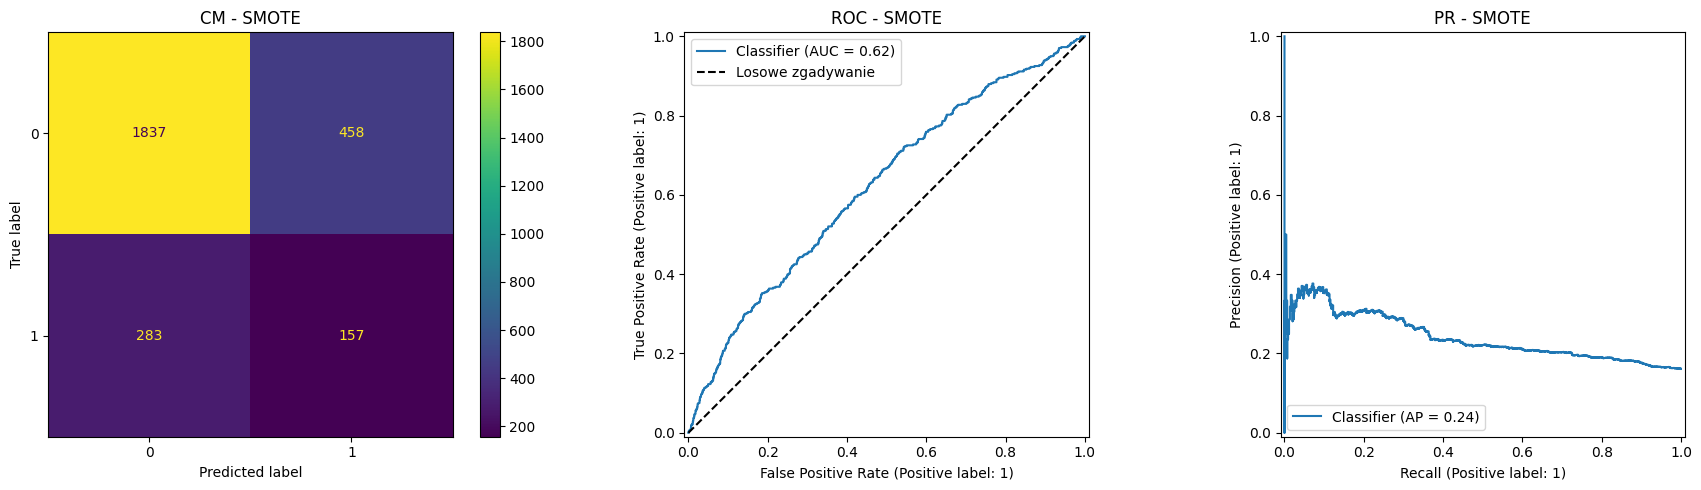

In [33]:
smote_model = train_and_plot_resampler("SMOTE",
                         ("SMOTE", SMOTE(random_state=42))
)

                   pre       rec       spe        f1       geo       iba       sup

          0       0.88      0.75      0.45      0.81      0.58      0.35      2295
          1       0.26      0.45      0.75      0.33      0.58      0.33       440

avg / total       0.78      0.70      0.50      0.73      0.58      0.34      2735



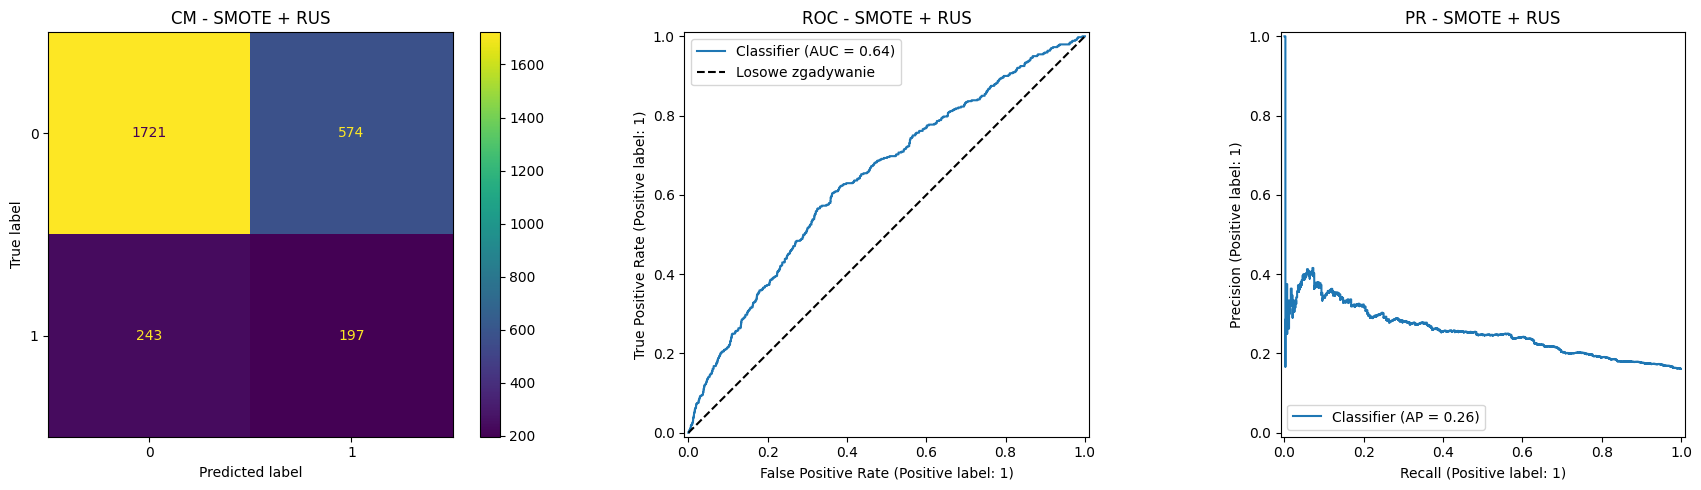

In [34]:
smote_rus_model = train_and_plot_resampler("SMOTE + RUS",
        ("smote", SMOTE(sampling_strategy=0.5, random_state=42)),
        ("RUS", RandomUnderSampler(sampling_strategy=1.0, random_state=42))
)

                   pre       rec       spe        f1       geo       iba       sup

          0       0.88      0.71      0.51      0.79      0.60      0.37      2295
          1       0.25      0.51      0.71      0.34      0.60      0.36       440

avg / total       0.78      0.68      0.54      0.72      0.60      0.37      2735



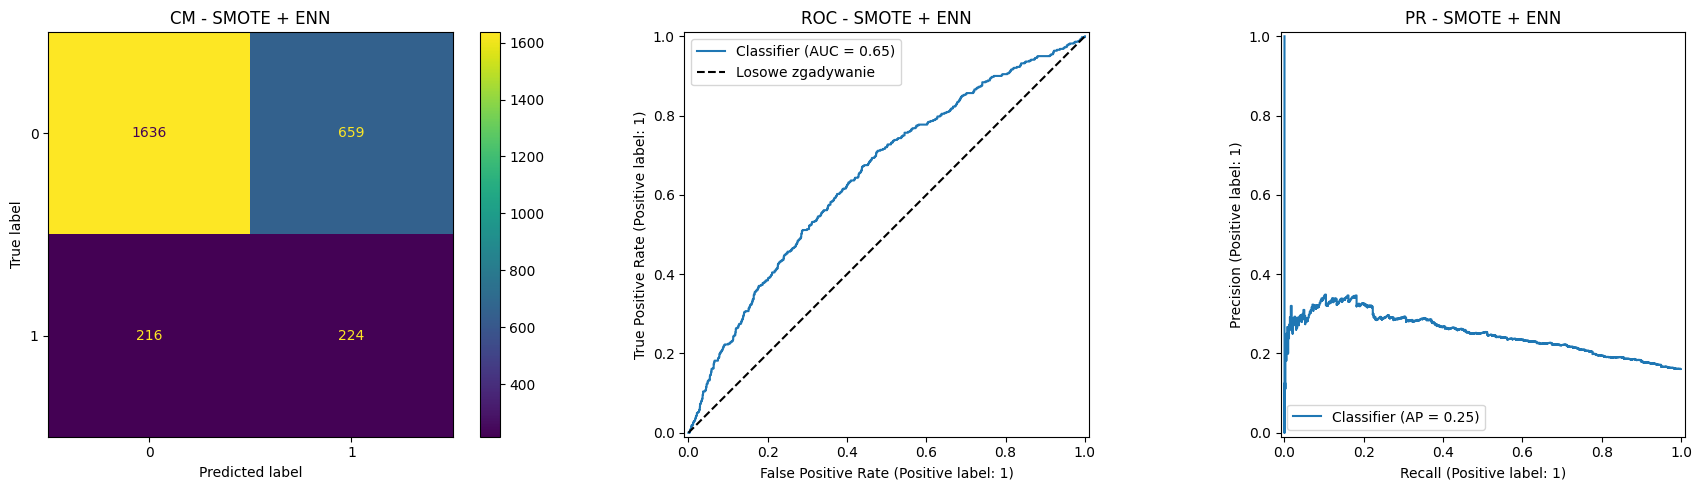

In [35]:
smoteen_model = train_and_plot_resampler(
    "SMOTE + ENN",
    ("SMOTEEN", SMOTEENN(random_state=42))
)

# Część 2

In [36]:
def precision_at_k(y_true, y_pred_proba, k=10):
    y_true_np = np.array(y_true)
    y_pred_proba_np = np.array(y_pred_proba)

    top_k_indices = np.argsort(y_pred_proba_np)[::-1][:k]

    top_k_true_labels = y_true_np[top_k_indices]

    return np.sum(top_k_true_labels) / k

def mean_reciprocal_rank(y_true, y_pred_proba):
    y_true_np = np.array(y_true)
    y_pred_proba_np = np.array(y_pred_proba)

    sorted_indices = np.argsort(y_pred_proba_np)[::-1]
    sorted_true_labels = y_true_np[sorted_indices]

    positive_ranks = np.where(sorted_true_labels == 1)[0]

    if len(positive_ranks) == 0:
        return 0.0

    first_positive_rank = positive_ranks[0] + 1
    return 1.0 / first_positive_rank

In [37]:
models = {
    "SMOTE": smote_model,
    "SMOTE + RUS": smote_rus_model,
    "SMOTE + ENN": smoteen_model,
    "RF": best_rf_model,
    "BRF": best_brf_model
}

for model_name, model in models.items():
    y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

    p_at_k = precision_at_k(y_test, y_pred_proba, 10)
    mrr = mean_reciprocal_rank(y_test, y_pred_proba)

    print(f"Model: {model_name}")
    print(f"  Precision@10: {p_at_k:.4f}")
    print(f"  MRR:          {mrr:.4f}\n")

Model: SMOTE
  Precision@10: 0.3000
  MRR:          0.3333

Model: SMOTE + RUS
  Precision@10: 0.3000
  MRR:          1.0000

Model: SMOTE + ENN
  Precision@10: 0.2000
  MRR:          0.1250

Model: RF
  Precision@10: 0.1000
  MRR:          0.1667

Model: BRF
  Precision@10: 0.2000
  MRR:          0.2000



Najlepsze parametry: {'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


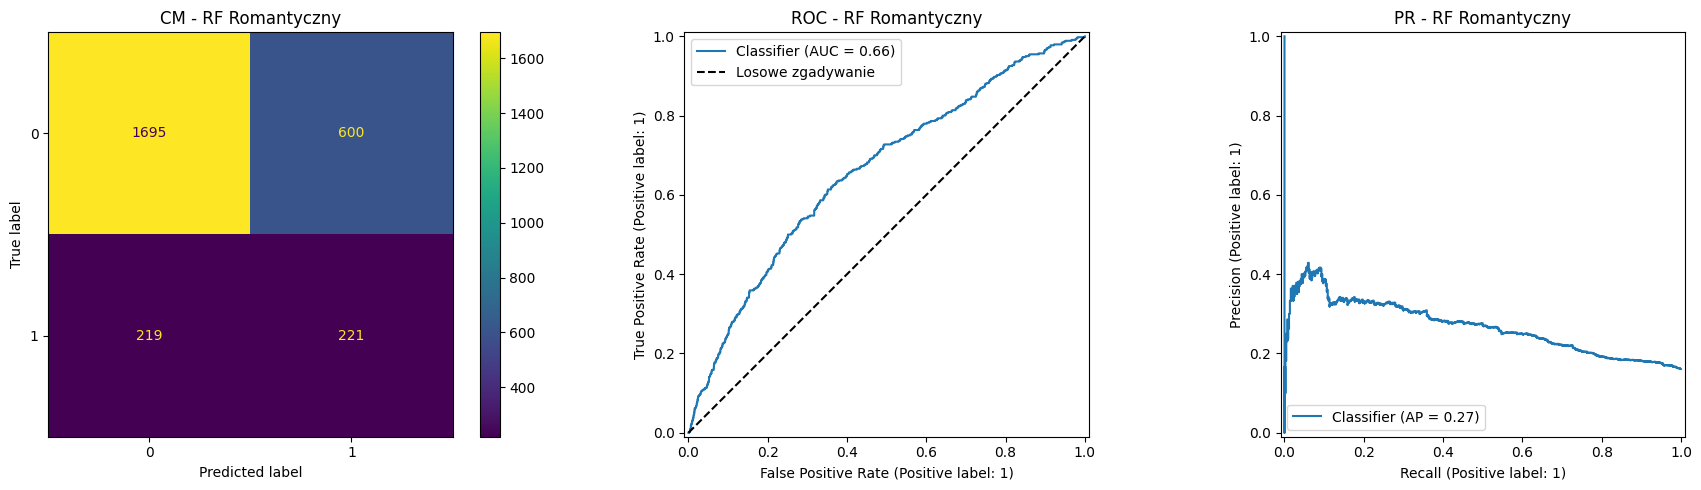

In [38]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2, 5, 10]
}

rf_romantic_base_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
])

rf_romantic_grid = GridSearchCV(
    estimator=rf_romantic_base_pipe,
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1,
)

rf_romantic_grid.fit(X_train_processed, y_train)

print(f"Najlepsze parametry: {rf_romantic_grid.best_params_}")

best_rf_romantic_model = rf_romantic_grid.best_estimator_

y_pred_rf_romantic = best_rf_romantic_model.predict(X_test_processed)
y_pred_proba_rf_romantic = best_rf_romantic_model.predict_proba(X_test_processed)[:, 1]

romantic_report = classification_report_imbalanced(y_test, y_pred_rf_romantic, output_dict=True)

plot_evaluation_metrics(y_test, y_pred_rf_romantic, y_pred_proba_rf_romantic, "RF Romantyczny")

Najlepsze parametry: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}


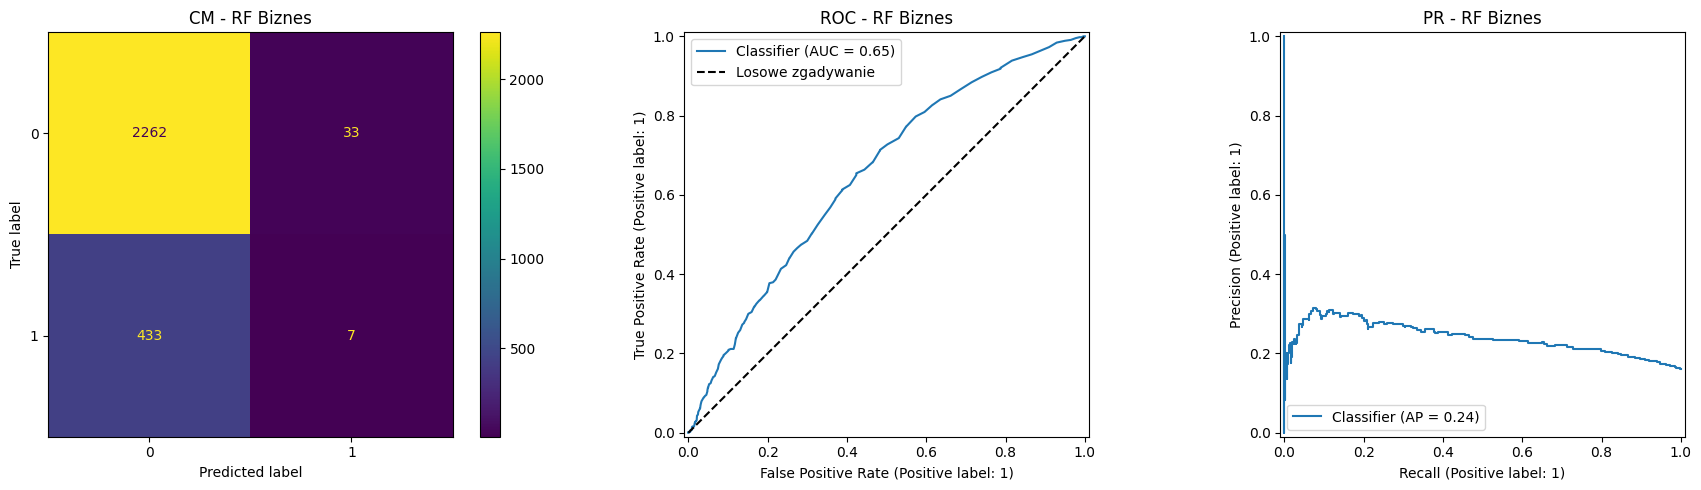

In [39]:
from sklearn.metrics import make_scorer, confusion_matrix

def custom_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    score = 50 * tp + 5 * fn + 10 * tn + (-20) * fp

    return score

custom_scorer = make_scorer(custom_score, greater_is_better=True)

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2, 5, 10]
}

rf_business_base_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
])

rf_business_grid = GridSearchCV(
    estimator=rf_base_pipe,
    param_grid=param_grid,
    scoring=custom_scorer,
    cv=5,
    n_jobs=-1,
)

rf_business_grid.fit(X_train_processed, y_train)

print(f"Najlepsze parametry: {rf_business_grid.best_params_}")
best_rf_business_model = rf_business_grid.best_estimator_

y_pred_rf_business = best_rf_business_model.predict(X_test_processed)
y_pred_proba_rf_business = best_rf_business_model.predict_proba(X_test_processed)[:, 1]

business_report = classification_report_imbalanced(y_test, y_pred_rf_business)

plot_evaluation_metrics(y_test, y_pred_rf_business, y_pred_proba_rf_business, "RF Biznes")

In [40]:
romantic_report = classification_report_imbalanced(y_test, y_pred_rf_romantic, output_dict=True)
business_report = classification_report_imbalanced(y_test, y_pred_rf_business, output_dict=True)

del business_report["0"]
del business_report["1"]
del romantic_report["0"]
del romantic_report["1"]

business_report["model"] = "biznesowy"
romantic_report["model"] = "romantyczny"

business_report["score"] = custom_score(y_test, y_pred_rf_business)
romantic_report["score"] = custom_score(y_test, y_pred_rf_romantic)

combined_report = pd.DataFrame([business_report, romantic_report])
combined_report

,avg_pre,avg_rec,avg_spe,avg_f1,avg_geo,avg_iba,total_support,model,score
0,0.732456,0.829616,0.171914,0.765452,0.125221,0.016712,2735,biznesowy,24475
1,0.786416,0.700548,0.540286,0.732234,0.609065,0.376905,2735,romantyczny,17095
